In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [18]:
df = pd.read_csv("data/challenge1_train.csv")
test = pd.read_csv("data/challenge1_test.csv")

print("Train shape:", df.shape)
print("Test shape:", test.shape)

Train shape: (7398, 10)
Test shape: (2467, 9)


In [20]:
df.head()

,ID,price,bathrooms,bedrooms,square_feet,latitude,longitude,category,has_photo,state
0,2,925,1.0,0,116,47.6160,-122.3275,housing/rent/apartment,Thumbnail,WA
1,3,2475,1.0,0,130,40.7629,-73.9885,housing/rent/apartment,Thumbnail,NY
2,5,1695,1.0,0,190,37.7599,-122.4379,housing/rent/apartment,Thumbnail,CA
3,6,1560,1.0,1,200,35.0847,-77.0609,housing/rent/apartment,Thumbnail,NC
4,7,1560,1.0,1,200,35.0960,-77.0272,housing/rent/apartment,Thumbnail,NC


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7398 entries, 0 to 7397
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           7398 non-null   int64  
 1   price        7398 non-null   int64  
 2   bathrooms    7398 non-null   float64
 3   bedrooms     7398 non-null   int64  
 4   square_feet  7398 non-null   int64  
 5   latitude     7398 non-null   float64
 6   longitude    7398 non-null   float64
 7   category     7398 non-null   object 
 8   has_photo    7398 non-null   object 
 9   state        7398 non-null   object 
dtypes: float64(3), int64(4), object(3)
memory usage: 578.1+ KB


In [24]:
print(df['category'].value_counts())
print()
print(df['has_photo'].value_counts())
print()
print(df['state'].value_counts())

category
housing/rent/apartment     7395
housing/rent/home             2
housing/rent/short_term       1
Name: count, dtype: int64

has_photo
Thumbnail    6566
Yes           693
No            139
Name: count, dtype: int64

state
TX    1327
CA     688
WA     375
MD     341
NC     340
NJ     294
GA     271
FL     249
OH     232
CO     230
WI     222
IL     203
MO     189
MN     170
IN     165
VA     149
OK     143
MI     137
OR     135
IA     134
PA     130
MA     119
ND      87
AZ      87
NV      86
CT      78
NE      78
TN      73
UT      65
DC      62
SC      60
KS      60
NY      56
NH      48
LA      46
SD      46
AL      40
AR      40
AK      34
KY      30
ID      19
VT      14
HI      10
NM       9
RI       8
MS       7
MT       5
DE       4
ME       2
WV       1
Name: count, dtype: int64


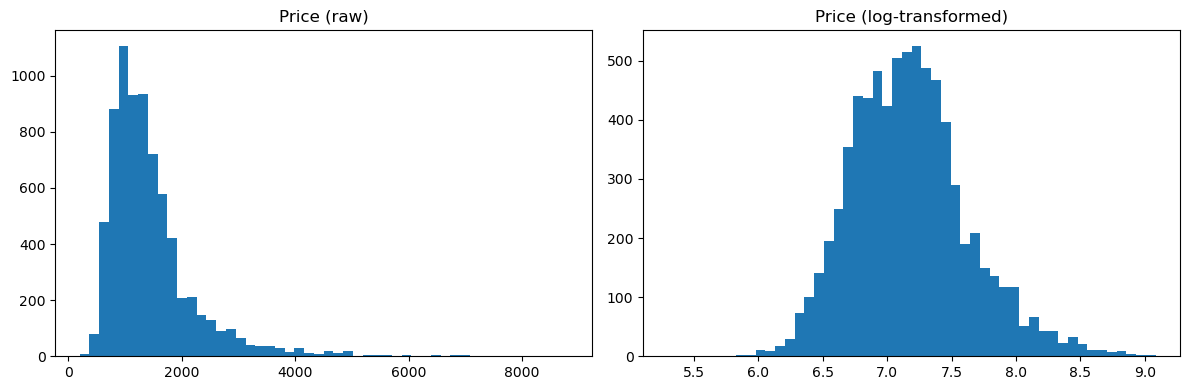

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price'], bins=50)
axes[0].set_title('Price (raw)')
axes[1].hist(np.log(df['price']), bins=50)
axes[1].set_title('Price (log-transformed)')
plt.tight_layout()
plt.show()

In [28]:
numeric_cols = ['price', 'bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude']
df[numeric_cols].corr()['price'].sort_values(ascending=False)

price          1.000000
square_feet    0.484285
bathrooms      0.444624
bedrooms       0.358349
latitude       0.039075
longitude     -0.192189
Name: price, dtype: float64

In [30]:
target = 'price'
features = ['bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude', 'has_photo', 'state']

In [32]:
train_split, val_split = train_test_split(df, test_size=0.2, random_state=42)

print("Train split:", train_split.shape)
print("Validation split:", val_split.shape)

train_split.to_csv('data/train_split.csv', index=False)
val_split.to_csv('data/val_split.csv', index=False)

Train split: (5918, 10)
Validation split: (1480, 10)


In [34]:
numeric_features = ['bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude']
categorical_features = ['has_photo', 'state']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [36]:
X_train_transformed = preprocessor.fit_transform(train_split[features])
X_val_transformed = preprocessor.transform(val_split[features])
X_test_transformed = preprocessor.transform(test[features])

print("Train transformed shape:", X_train_transformed.shape)
print("Validation transformed shape:", X_val_transformed.shape)
print("Test transformed shape:", X_test_transformed.shape)

Train transformed shape: (5918, 58)
Validation transformed shape: (1480, 58)
Test transformed shape: (2467, 58)


In [38]:
print(df['bedrooms'].value_counts().sort_index())
print()
print(df['bathrooms'].value_counts().sort_index())

bedrooms
0     137
1    3416
2    2521
3     954
4     291
5      66
6       8
7       2
8       2
9       1
Name: count, dtype: int64

bathrooms
1.0    4912
1.5     207
2.0    1830
2.5     222
3.0     124
3.5      55
4.0      33
4.5       7
5.0       6
5.5       1
7.0       1
Name: count, dtype: int64
